# DeepSeek-OCR × CUAD: Unbiased Distorted-Rendering Compression

**Goal.** Use [DeepSeek-OCR](https://github.com/deepseek-ai/DeepSeek-OCR) to compress CUAD contracts into vision tokens, using a **question-agnostic** distorted rendering driven by a MemSlot attention module on top of frozen RoBERTa. Compare against saliency-pruning and API-summarization on the same QA reader, scored with CUAD-official metrics (EM / F1 / AUPR / P@80%R).

### Why this notebook is leakage-free
1. The saliency module is **trained only on CUAD train-split *contracts*** with an unsupervised reconstruction + slot-diversity loss. No question, no answer, no clause category ever enters training.
2. Evaluation uses the held-out CUAD **test split**; the `MemSlotSaliency` model has never seen those contracts.
3. The QA reader (DeepSeek / Qwen chat API) is invoked identically for every compression arm, so the only variable is the compressed context.

### Runtime
Colab **A100-40G** recommended. L4 / A10G works. T4 will fail — DeepSeek-OCR requires FlashAttention-2 + bfloat16. M1/M2 MacBook: **not supported**.

## 0. Environment

In [ ]:
import os

# One of these is required for the baseline + eval cells.
# Colab: Runtime -> Secrets -> add DEEPSEEK_API_KEY (preferred) or DASHSCOPE_API_KEY.
try:
    from google.colab import userdata
    for name in ('DEEPSEEK_API_KEY', 'DASHSCOPE_API_KEY', 'OPENAI_API_KEY'):
        try:
            v = userdata.get(name)
            if v:
                os.environ[name] = v
        except Exception:
            pass
except Exception:
    pass

assert (os.environ.get('DEEPSEEK_API_KEY') or os.environ.get('DASHSCOPE_API_KEY') or os.environ.get('OPENAI_API_KEY')), \
    'Set DEEPSEEK_API_KEY / DASHSCOPE_API_KEY / OPENAI_API_KEY (recommended: Colab Secrets).'

!nvidia-smi | head -6 || echo 'WARNING: no NVIDIA GPU detected -- DeepSeek-OCR requires A100/L4/A10G.'


In [6]:
%%bash
set -e
pip -q install 'transformers==4.46.3' 'tokenizers==0.20.3' 'accelerate>=0.34,<1.1' einops addict easydict
pip -q install Pillow matplotlib seaborn pandas requests tqdm
# NOTE: flash-attn is intentionally NOT installed here. PyTorch's built-in
# SDPA backend already dispatches to FlashAttention-2 kernels on
# Ampere/Ada/Hopper GPUs in bf16/fp16, so the wrapper in
# deepseek_pipeline/ocr_compress.py loads the model with
# _attn_implementation="sdpa" by default. This avoids the ~1 h source
# build that happens when no prebuilt flash-attn wheel matches your
# torch / cuda / python combination (e.g. torch 2.10 + cu128 + cp312).
#
# If you really want the external package and have a matching prebuilt
# wheel, install it manually before instantiating DeepSeekOCRCompressor:
#     pip install flash-attn==2.7.3 --no-build-isolation
# and then pass attn_implementation="flash_attention_2".


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 173.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 131.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.9/330.9 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.4 MB/s eta 0:00:00


In [7]:
%cd /content
!git clone https://github.com/KuiyiGao/Distorted-OCR-Compression.git 2>/dev/null || (cd Distorted-OCR-Compression && git pull)
%cd /content/Distorted-OCR-Compression
import sys; sys.path.insert(0, '/content/Distorted-OCR-Compression')

/content
/content/Distorted-OCR-Compression


## 1. Load CUADv1 and split by **document**

Split at the contract level (not the QA level) so that a contract seen in training cannot reappear at test time. We also keep the held-out test QAs around purely for the final evaluation — they are never forwarded to the saliency model.

In [8]:
import json, random, urllib.request, zipfile, io
from pathlib import Path

random.seed(0)
N_TEST_DOCS = 10           # held-out contracts
N_TEST_QAS_PER_DOC = 3      # sample a few questions per test contract

CUAD_PATH = Path('render/data/CUADv1.json')
if not CUAD_PATH.exists():
    CUAD_PATH.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen('https://raw.githubusercontent.com/TheAtticusProject/cuad/main/data.zip') as r:
        with zipfile.ZipFile(io.BytesIO(r.read())) as z:
            with z.open('CUADv1.json') as src, open(CUAD_PATH, 'wb') as dst:
                dst.write(src.read())
cuad = json.load(open(CUAD_PATH))['data']
random.shuffle(cuad)

test_docs = cuad[:N_TEST_DOCS]
train_docs = cuad[N_TEST_DOCS:]

train_contexts = [p['context'] for doc in train_docs for p in doc['paragraphs']]
test_items = []
for doc in test_docs:
    for para in doc['paragraphs']:
        ctx = para['context']
        qas = list(para['qas'])
        random.shuffle(qas)
        for qa in qas[:N_TEST_QAS_PER_DOC]:
            test_items.append({'qa_id': qa['id'], 'question': qa['question'],
                               'context': ctx, 'gold': [a['text'] for a in qa['answers']]})

print(f'train: {len(train_docs)} docs -> {len(train_contexts)} contexts | test: {len(test_docs)} docs -> {len(test_items)} QAs')


train: 500 docs -> 500 contexts | test: 10 docs -> 30 QAs


## 2. Train the MemSlot saliency module on train-split contracts only

Frozen RoBERTa-base backbone; only the MemSlot parameters move. The objective is *reconstruction + slot-diversity* — no QA labels are consumed.

In [9]:
from deepseek_pipeline import MemSlotSaliency, MemSlotConfig

cfg = MemSlotConfig(n_slots=32, epochs=2, batch_size=8, max_length=512, stride=256)
memslot = MemSlotSaliency(backbone_name='roberta-base', config=cfg)

# Use a manageable slice of contexts; plenty for unsupervised slot training.
train_sample = train_contexts[:200]
memslot.train_on_contracts(train_sample)
memslot.save('/content/memslot.pt')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[MemSlot] training on 9987 windows from 200 contracts
  epoch 1/2  loss=0.0676
  epoch 2/2  loss=0.0506


## 3. Saliency-driven distorted render on **test** contracts

The saliency score here is a function of the contract only — the test question is *not* visible to the renderer.

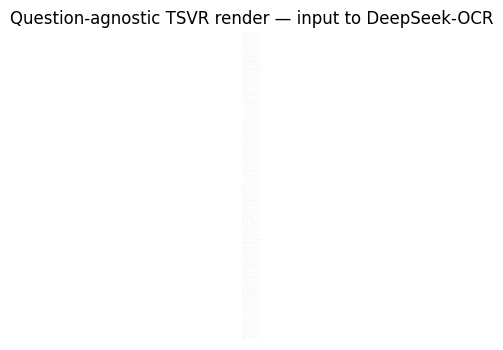

In [10]:
import os, hashlib
from render.render import render_tsvr_image

os.makedirs('/content/renders', exist_ok=True)
context_cache = {}
for s in test_items:
    key = hashlib.md5(s['context'].encode()).hexdigest()[:16]
    if key not in context_cache:
        ww = memslot.word_weights(s['context'])
        img = render_tsvr_image(ww, image_width=1024, max_font_size=56)
        path = f'/content/renders/{key}.png'
        img.save(path)
        context_cache[key] = {'word_weights': ww, 'image': path}
    s.update(context_cache[key])

from PIL import Image; import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4)); plt.imshow(Image.open(test_items[0]['image'])); plt.axis('off')
plt.title('Question-agnostic TSVR render — input to DeepSeek-OCR'); plt.show()

## 4. Run the three compression arms

In [11]:
from deepseek_pipeline import DeepSeekOCRCompressor, SaliencyPruner, ApiSummarizer

_PROVIDER = 'deepseek' if os.environ.get('DEEPSEEK_API_KEY') else 'qwen'

ocr = DeepSeekOCRCompressor()
pruner = SaliencyPruner(memslot.tokenizer)
summarizer = ApiSummarizer(memslot.tokenizer, provider=_PROVIDER)

# keep this sweep lean to limit API usage
OCR_MODES      = ['tiny', 'base']                   # 64 and 256 vision tokens
PRUNE_KEEPS    = [0.05, 0.20]
SUMMARY_TARGETS = [64, 256]                          # match OCR budgets

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

modeling_deepseekocr.py: 0.00B [00:00, ?B/s]

...

conversation.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/deepseek-ai/DeepSeek-OCR:
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/deepseek-ai/DeepSeek-OCR:
- modeling_deepseekocr.py
- configuration_deepseek_v2.py
- deepencoder.py
- modeling_deepseekv2.py
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-000001.safetensors:   0%|          | 0.00/6.67G [00:00<?, ?B/s]

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at deepseek-ai/DeepSeek-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
from tqdm.auto import tqdm

all_runs = []
# per-context caches so we don't recompute OCR / summaries per question
ocr_cache, summary_cache = {}, {}

for s in tqdm(test_items, desc='compress'):
    n_orig = len(memslot.tokenizer.encode(s['context'], add_special_tokens=False))
    ctx_key = hashlib.md5(s['context'].encode()).hexdigest()[:16]

    for mode in OCR_MODES:
        k = (ctx_key, mode)
        if k not in ocr_cache:
            ocr_cache[k] = ocr.compress(s['image'], mode=mode)
        r = ocr_cache[k]
        all_runs.append({'qa_id': s['qa_id'], 'question': s['question'], 'gold': s['gold'],
                         'method': f'ocr-{mode}', 'context': r.decoded_text,
                         'n_original_tokens': n_orig, 'n_compressed_tokens': r.n_vision_tokens})

    for keep in PRUNE_KEEPS:
        r = pruner.compress(s['word_weights'], keep_ratio=keep)
        all_runs.append({'qa_id': s['qa_id'], 'question': s['question'], 'gold': s['gold'],
                         'method': f'prune@{keep:.2f}', 'context': r.text,
                         'n_original_tokens': n_orig, 'n_compressed_tokens': r.n_tokens})

    for tgt in SUMMARY_TARGETS:
        k = (ctx_key, tgt)
        if k not in summary_cache:
            try:
                # no question passed to keep the arm question-agnostic
                summary_cache[k] = summarizer.compress(s['context'], target_tokens=tgt, question=None)
            except Exception as e:
                print('summary err:', e); summary_cache[k] = None
        r = summary_cache[k]
        if r is None:
            continue
        all_runs.append({'qa_id': s['qa_id'], 'question': s['question'], 'gold': s['gold'],
                         'method': f'summary@{tgt}', 'context': r.text,
                         'n_original_tokens': n_orig, 'n_compressed_tokens': r.n_tokens})

# full-context ceiling
for s in test_items:
    n_orig = len(memslot.tokenizer.encode(s['context'], add_special_tokens=False))
    all_runs.append({'qa_id': s['qa_id'], 'question': s['question'], 'gold': s['gold'],
                     'method': 'full-context', 'context': s['context'],
                     'n_original_tokens': n_orig, 'n_compressed_tokens': n_orig})
print('total runs:', len(all_runs))

compress:   0%|          | 0/30 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (16243 > 512). Running this sequence through the model will result in indexing errors


directly resize


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.
`get_max_cache()` is deprecated for all Cache classes. Use `get_max_cache_shape()` instead. Cal

BASE:  torch.Size([1, 64, 1280])
NO PATCHES
<|ref|>image<|/ref|><|det|>[[0, 0, 999, 999]]<|/det|>


...

BASE:  torch.Size([1, 256, 1280])
NO PATCHES
<|ref|>image<|/ref|><|det|>[[0, 0, 0, 0]]<|/det|>
directly resize


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


BASE:  torch.Size([1, 64, 1280])
NO PATCHES
<|ref|>image<|/ref|><|det|>[[44, 0, 945, 997]]<|/det|>


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


BASE:  torch.Size([1, 256, 1280])
NO PATCHES
<|ref|>text<|/ref|><|det|>[[0, 0, 0, 0]]<|/det|>
0
total runs: 210


## 5. QA evaluation with CUAD-official metrics

Every arm is scored by the same reader with a JSON-constrained reply so we can collect both an answer and a 1-5 confidence for the AUPR / P@80%R curves.

In [13]:
from deepseek_pipeline import ApiQAReader
reader = ApiQAReader(provider=_PROVIDER)

for run in tqdm(all_runs, desc='QA'):
    try:
        res = reader.score(run['context'], run['question'], run['gold'])
        run['prediction'], run['em'], run['f1'], run['confidence'] = res.prediction, res.em, res.f1, res.confidence
    except Exception as e:
        run['prediction'], run['em'], run['f1'], run['confidence'] = '', 0.0, 0.0, 0.0
        run['error'] = str(e)

QA:   0%|          | 0/210 [00:00<?, ?it/s]

In [14]:
import pandas as pd, numpy as np
from deepseek_pipeline import cuad_evaluate

df = pd.DataFrame(all_runs)
df['compression_ratio'] = df['n_original_tokens'] / df['n_compressed_tokens'].clip(lower=1)
df.to_csv('/content/cuad_results.csv', index=False)

rows = []
for method, sub in df.groupby('method'):
    s = cuad_evaluate(sub['prediction'].tolist(), sub['gold'].tolist(),
                      confidences=sub['confidence'].tolist())
    rows.append({'method': method, 'EM': s.em, 'F1': s.f1, 'AUPR': s.aupr,
                 'P@80%R': s.precision_at_80_recall, 'ratio': sub['compression_ratio'].mean(), 'n': s.n})
summary = pd.DataFrame(rows).sort_values('ratio', ascending=False).set_index('method')
summary

,EM,F1,AUPR,P@80%R,ratio,n
method,,,,,,
ocr-tiny,0.633333,0.633333,0.000000,0.0,162.703125,30
summary@64,0.633333,0.659343,0.000000,0.0,137.318271,30
ocr-base,0.633333,0.633333,0.000000,0.0,40.675781,30
summary@256,0.633333,0.671413,0.009091,0.0,31.135978,30
prune@0.05,0.633333,0.633333,0.000000,0.0,15.108084,30
prune@0.20,0.600000,0.637160,0.000000,0.0,4.538667,30
full-context,0.633333,0.754757,0.147032,0.0,1.000000,30


## 6. Visualization

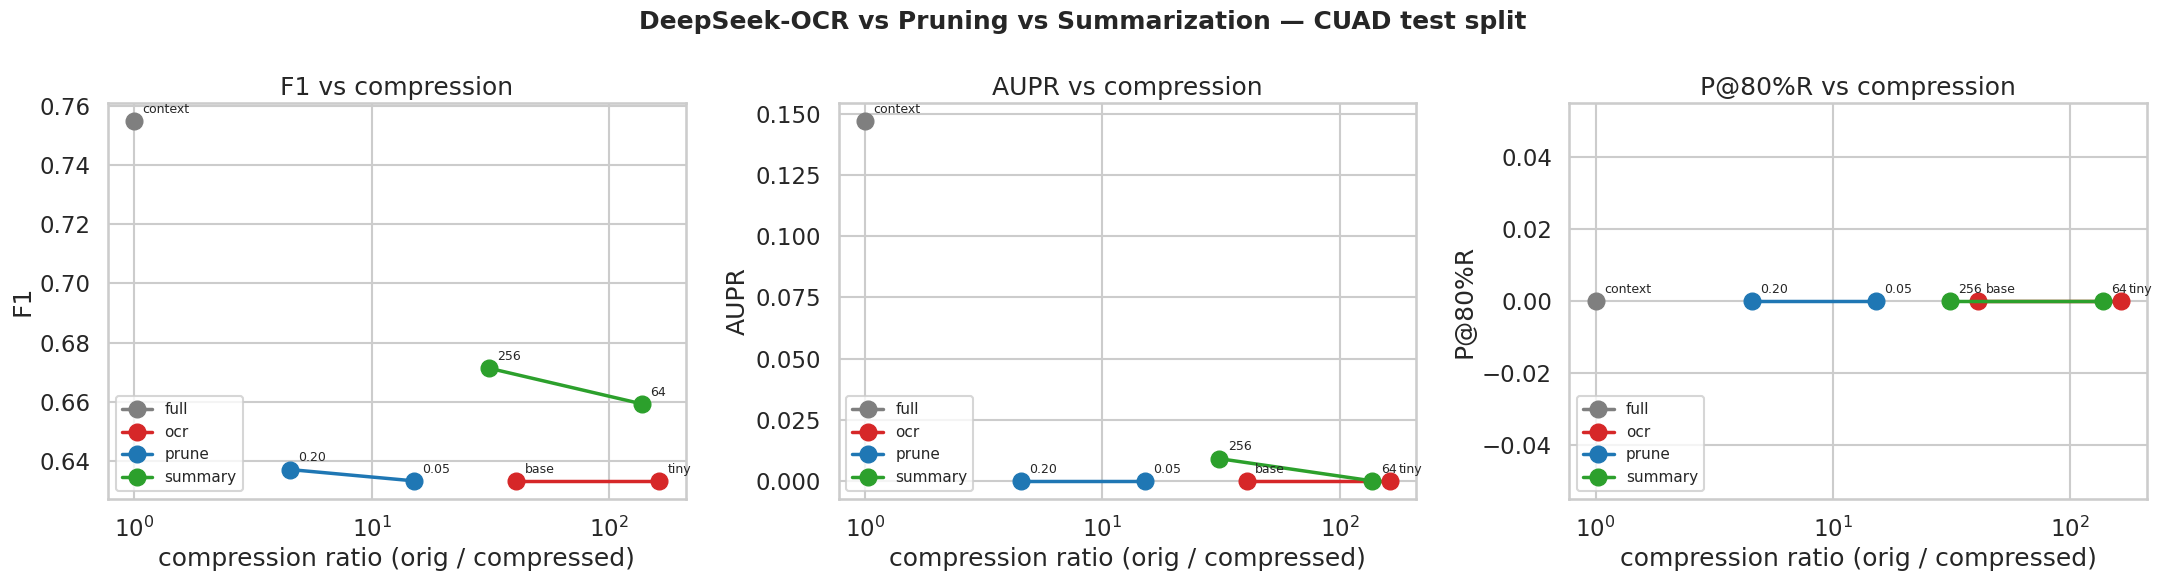

In [15]:
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

palette = {'ocr': '#d62728', 'prune': '#1f77b4', 'summary': '#2ca02c', 'full': '#7f7f7f'}
fam = lambda m: 'ocr' if m.startswith('ocr') else 'prune' if m.startswith('prune') else 'summary' if m.startswith('summary') else 'full'

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, metric in zip(axes, ['F1', 'AUPR', 'P@80%R']):
    for f, sub in summary.assign(family=lambda d: d.index.map(fam)).groupby('family'):
        sub = sub.sort_values('ratio')
        ax.plot(sub['ratio'], sub[metric], 'o-', color=palette[f], lw=2.5, ms=12, label=f)
        for idx, row in sub.iterrows():
            ax.annotate(idx.split('-')[-1].split('@')[-1], (row['ratio'], row[metric]),
                        textcoords='offset points', xytext=(6, 6), fontsize=9)
    ax.set_xscale('log'); ax.set_xlabel('compression ratio (orig / compressed)'); ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs compression'); ax.legend(loc='lower left', fontsize=11)
plt.suptitle('DeepSeek-OCR vs Pruning vs Summarization — CUAD test split', fontsize=18, fontweight='bold')
plt.tight_layout(); plt.savefig('/content/pareto.png', dpi=150); plt.show()

/tmp/ipykernel_28535/2952927954.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.savefig('/content/heatmap.png', dpi=150); plt.show()


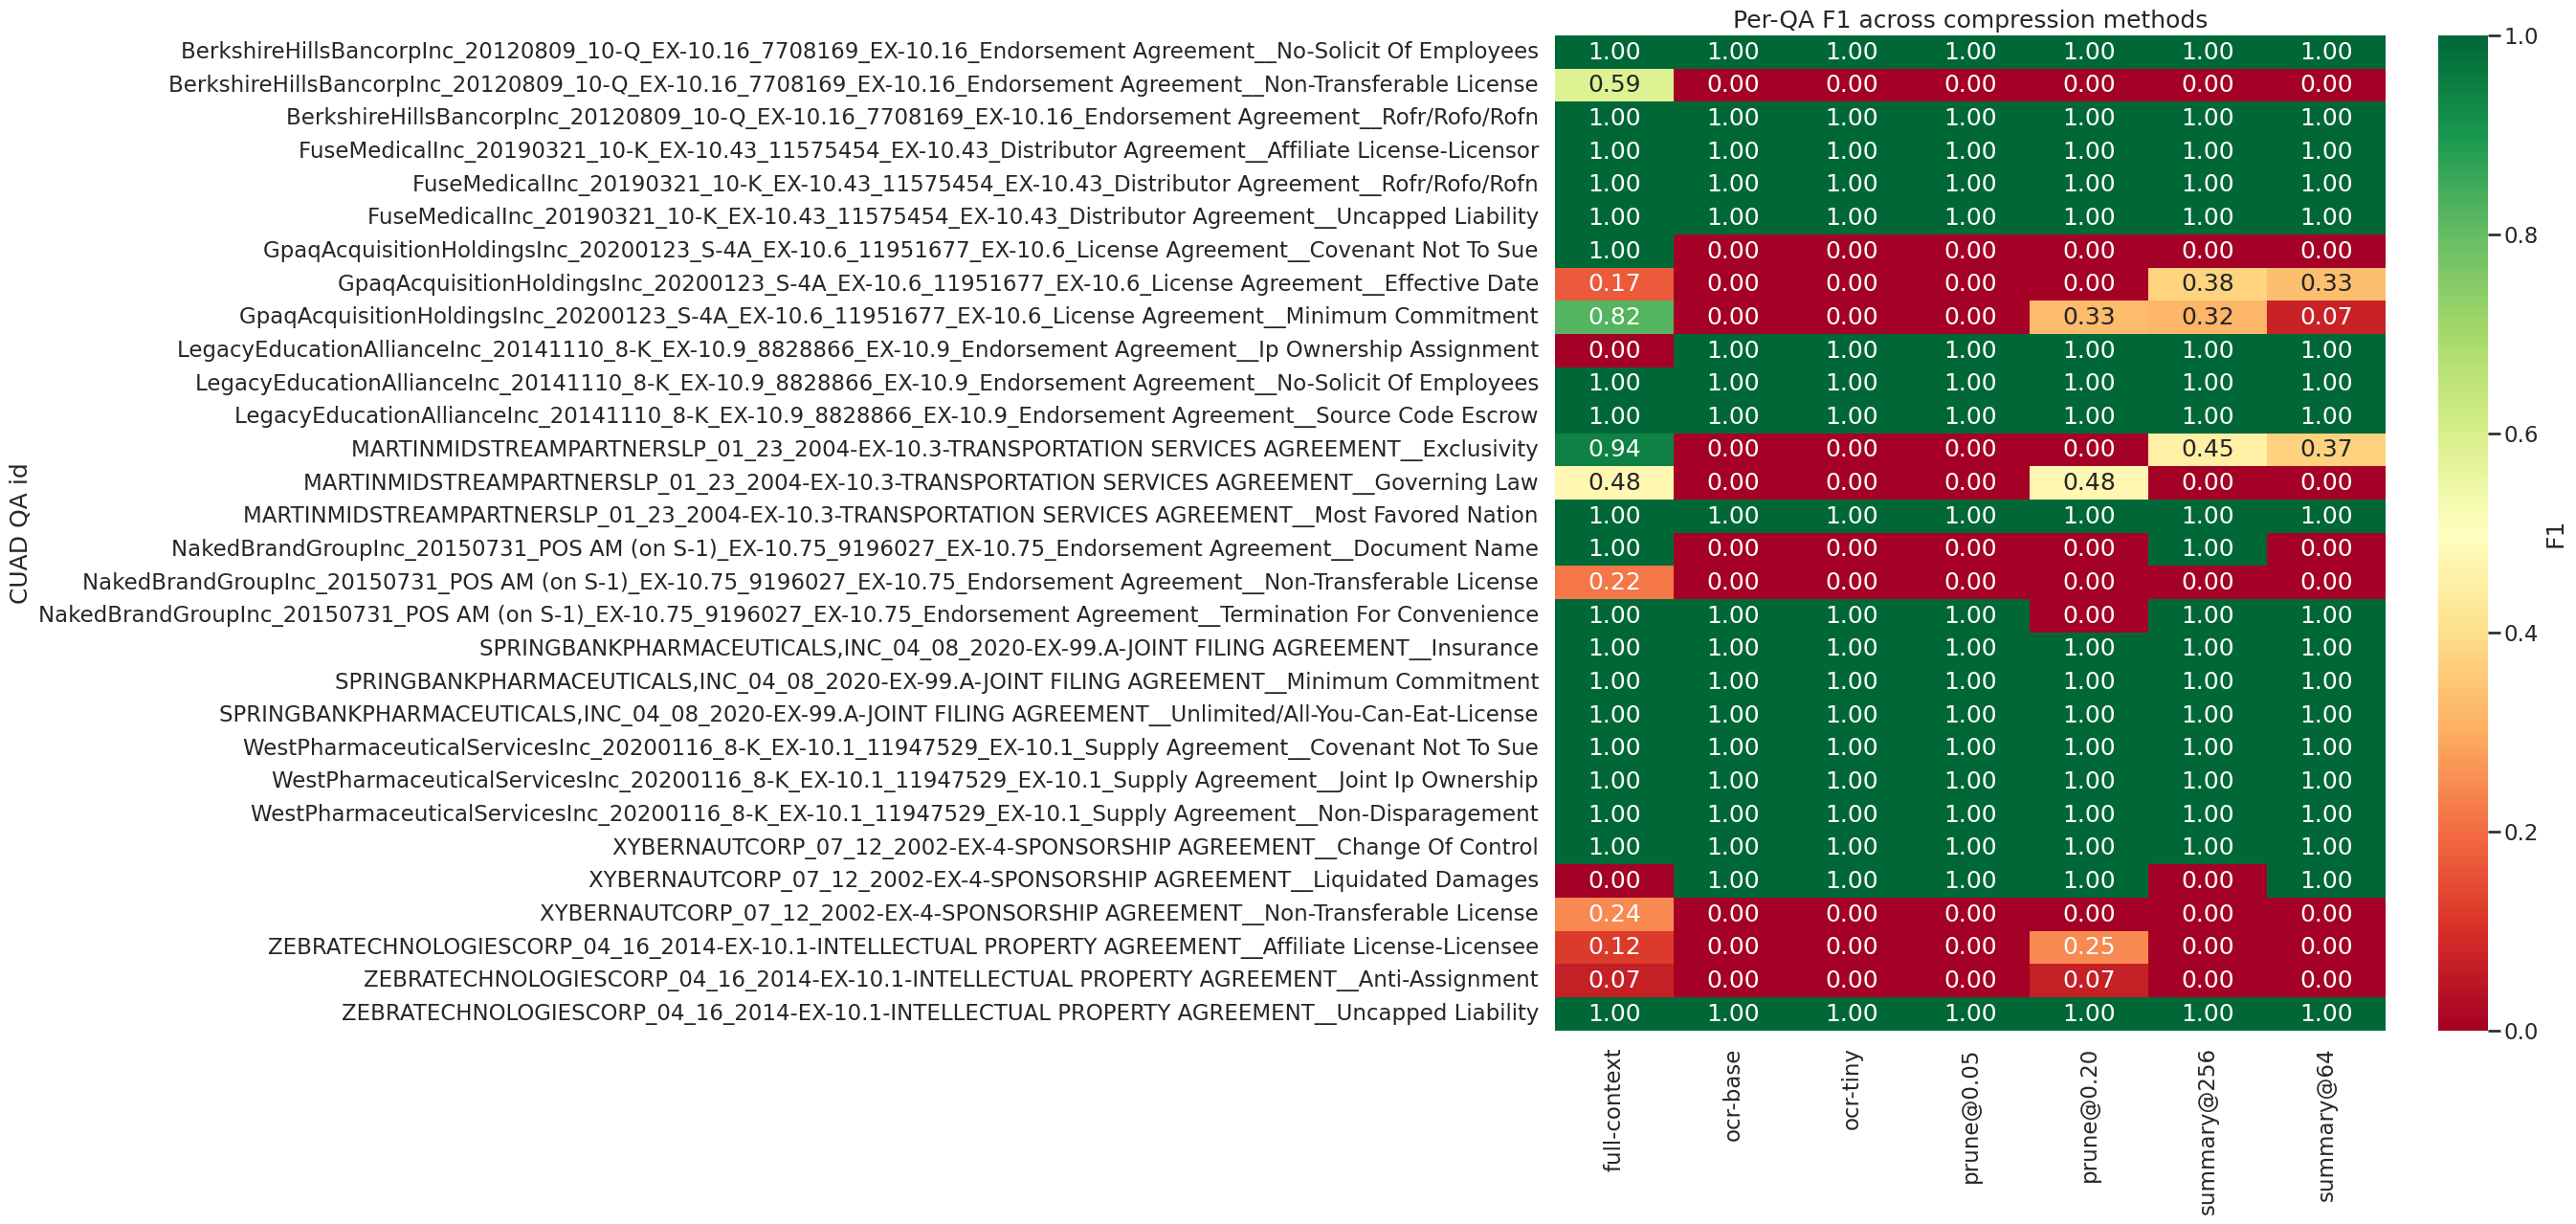

In [16]:
# per-sample F1 heatmap — which contract is hard for which method?
pivot = df.pivot_table(index='qa_id', columns='method', values='f1')
fig, ax = plt.subplots(figsize=(14, max(3, 0.45 * len(pivot))))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, cbar_kws={'label': 'F1'}, ax=ax)
ax.set_title('Per-QA F1 across compression methods'); ax.set_xlabel(''); ax.set_ylabel('CUAD QA id')
plt.tight_layout(); plt.savefig('/content/heatmap.png', dpi=150); plt.show()

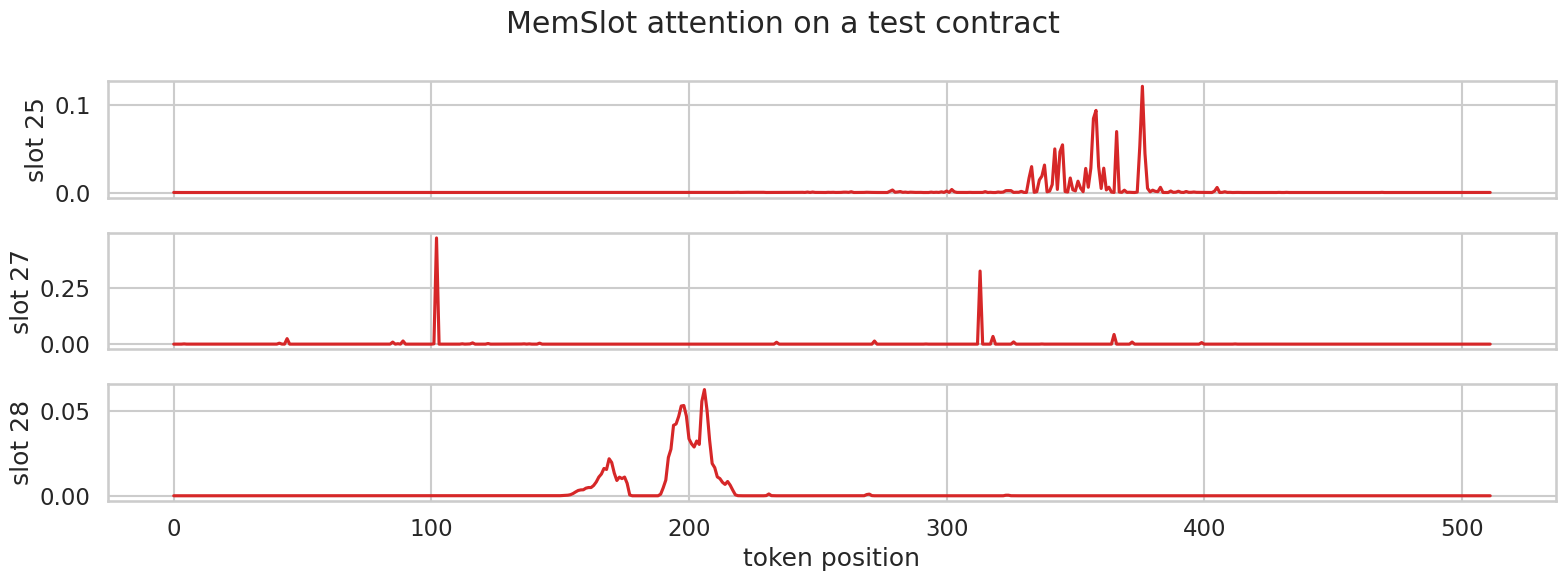

In [17]:
# MemSlot qualitative view: show the top-3 slots' attention traces on one contract
import torch, numpy as np
s = test_items[0]
enc = memslot.tokenizer(s['context'], truncation=True, max_length=512, return_offsets_mapping=True,
                        padding='max_length', return_tensors='pt')
with torch.no_grad():
    H = memslot.backbone(input_ids=enc['input_ids'].to(memslot.device),
                         attention_mask=enc['attention_mask'].to(memslot.device)).last_hidden_state
    _, attn, _ = memslot.memslot(H, mask=enc['attention_mask'].to(memslot.device).bool())
attn = attn.squeeze(0).cpu().numpy()                        # (K, L)
top_slots = attn.sum(-1).argsort()[-3:]
fig, axes = plt.subplots(3, 1, figsize=(16, 6), sharex=True)
for ax, k in zip(axes, top_slots):
    ax.plot(attn[k], color='#d62728'); ax.set_ylabel(f'slot {k}')
axes[-1].set_xlabel('token position'); plt.suptitle('MemSlot attention on a test contract'); plt.tight_layout(); plt.show()

## 7. Artifacts

`cuad_results.csv`, `pareto.png`, `heatmap.png`, `memslot.pt`, and the rendered PNGs under `/content/renders/`.